<a href="https://colab.research.google.com/github/nickcanoy/Masters_in_DataScience/blob/main/Explaining_Visually_to_Influence_with_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Hands-On Activity 3-1 | Explaining Visually to Influence with Data**





---



PSMDSSC 102-PSMDS12G2 - Data Visualization

Name : **RODENICK CANOY**

Date Submitted : March 24, 2026



---



Step 1. Import Libraries and Create an Analytical Dataset

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style="whitegrid")

# Sample dataset for a decision-oriented communication task
data = {
    "Month": ["Jan", "Feb", "Mar", "Apr", "May", "Jun"],
    "Sales": [200, 250, 180, 300, 280, 350],
    "Marketing_Spend": [50, 60, 45, 70, 65, 80]
}

df = pd.DataFrame(data)

# Derived metrics to support higher-level interpretation
df["Sales_Growth_%"] = df["Sales"].pct_change() * 100
df["Marketing_Efficiency"] = df["Sales"] / df["Marketing_Spend"]
df["Marketing_Intensity_%"] = (df["Marketing_Spend"] / df["Sales"]) * 100

df.round(2)

,Month,Sales,Marketing_Spend,Sales_Growth_%,Marketing_Efficiency,Marketing_Intensity_%
0,Jan,200,50,NaN,4.00,25.00
1,Feb,250,60,25.00,4.17,24.00
2,Mar,180,45,-28.00,4.00,25.00
3,Apr,300,70,66.67,4.29,23.33
4,May,280,65,-6.67,4.31,23.21
5,Jun,350,80,25.00,4.38,22.86


Step 2. Frame the Visualization for a Specific Audience

Below are two contrasting views of the same dataset. Notice that the **executive view** emphasizes the headline pattern, while the **analyst view** provides additional context and supporting metrics. This requires deliberate control over what is shown, what is omitted, and why.

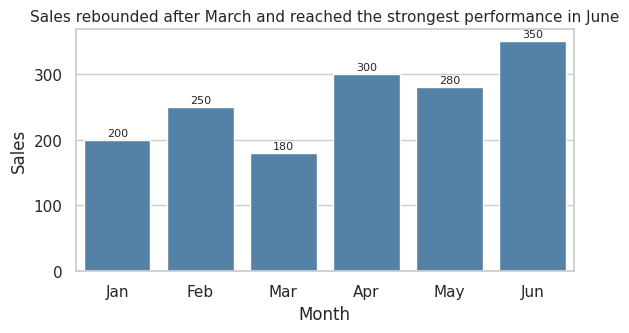

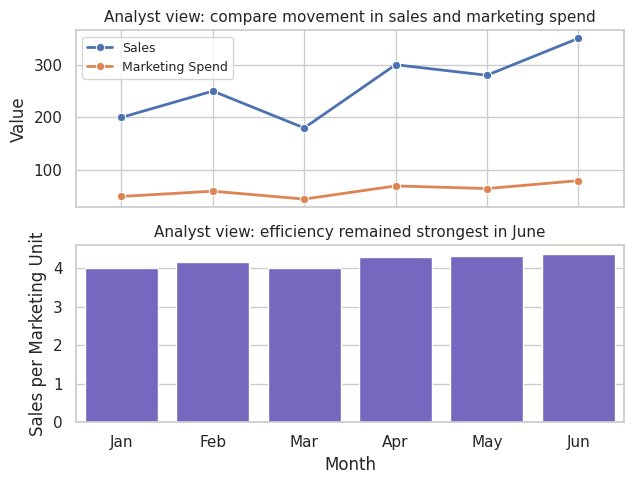

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style="whitegrid")

# Sample dataset for a decision-oriented communication task
data = {
    "Month": ["Jan", "Feb", "Mar", "Apr", "May", "Jun"],
    "Sales": [200, 250, 180, 300, 280, 350],
    "Marketing_Spend": [50, 60, 45, 70, 65, 80]
}

df = pd.DataFrame(data)

# Derived metrics to support higher-level interpretation
df["Sales_Growth_%"] = df["Sales"].pct_change() * 100
df["Marketing_Efficiency"] = df["Sales"] / df["Marketing_Spend"]
df["Marketing_Intensity_%"] = (df["Marketing_Spend"] / df["Sales"]) * 100

plt.figure(figsize=(6, 3.5))
ax = sns.barplot(x="Month", y="Sales", data=df, color="steelblue")
ax.set_title(
    "Sales rebounded after March and reached the strongest performance in June",
    fontsize=11
)
ax.set_ylabel("Sales")

for i, value in enumerate(df["Sales"]):
    ax.text(i, value + 6, f"{value}", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(6.5, 5), sharex=True)

sns.lineplot(
    x="Month", y="Sales", data=df,
    marker="o", linewidth=2, label="Sales", ax=axes[0]
)
sns.lineplot(
    x="Month", y="Marketing_Spend", data=df,
    marker="o", linewidth=2, label="Marketing Spend", ax=axes[0]
)
axes[0].set_title(
    "Analyst view: compare movement in sales and marketing spend",
    fontsize=11
)
axes[0].set_ylabel("Value")
axes[0].legend(fontsize=9)

sns.barplot(
    x="Month", y="Marketing_Efficiency",
    data=df, color="slateblue", ax=axes[1]
)
axes[1].set_title(
    "Analyst view: efficiency remained strongest in June",
    fontsize=11
)
axes[1].set_ylabel("Sales per Marketing Unit")

plt.tight_layout()
plt.show()

**Your Task 1:** Select **one** audience below and create a visualization optimized for that audience.

- Executive committee deciding whether to increase marketing investment
- Operations manager monitoring month-to-month performance stability
- Investor looking for evidence of growth momentum
- Technical analyst interested in detailed trend behavior

Your output must include:
1. One visualization designed for the chosen audience  
2. A takeaway title that states the main message  
3. A **4-6 sentence justification** explaining the chart type, visual encoding, level of detail, and the decision it is intended to influence

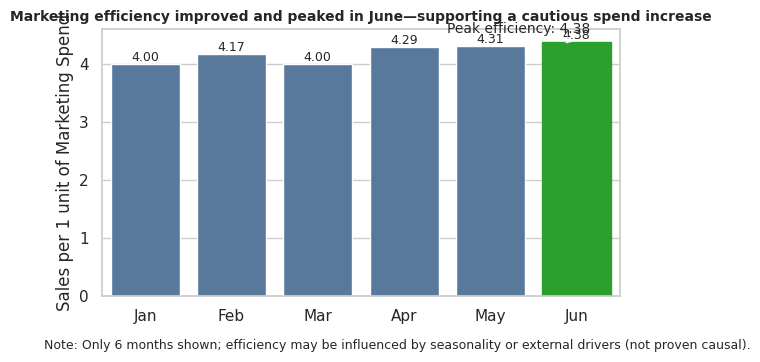

In [ ]:
#Audience-specific visualization

plt.figure(figsize=(6,3.5))

ax = sns.barplot(
    x="Month", y="Marketing_Efficiency", data=df,
    color="#4C78A8"
)

# Takeaway title (actionable)
ax.set_title("Marketing efficiency improved and peaked in June—supporting a cautious spend increase",
             fontsize=10, weight="bold")
ax.set_ylabel("Sales per 1 unit of Marketing Spend")
ax.set_xlabel("")

# Minimal labels (only key point + last value)
jun_idx = df.index[df["Month"]=="Jun"][0]
jun_val = df.loc[jun_idx, "Marketing_Efficiency"]

ax.bar_label(ax.containers[0], fmt="%.2f", fontsize=9)

# Highlight June bar
ax.patches[jun_idx].set_color("#2CA02C")

# Annotation: key evidence
ax.annotate(f"Peak efficiency: {jun_val:.2f}",
            xy=(jun_idx, jun_val),
            xytext=(jun_idx-1.5, jun_val+0.15),
            arrowprops=dict(arrowstyle="->", lw=1),
            fontsize=10)

# Limitation note (ethical restraint)
plt.figtext(0.01, -0.02,
            "Note: Only 6 months shown; efficiency may be influenced by seasonality or external drivers (not proven causal).",
            ha="left", fontsize=9)

plt.tight_layout()
plt.show()

DESIGN JUSTIFICATION:

* This chart minimizes cognitive load by isolating a single, high-impact metric: marketing efficiency.

* A clean bar chart allows the commitee to compare performance across months instantly, without the clutter of multiple scales.

* The "takeaway" title and highlighted June data prime the audience for the recommendation: a cautious increase in spend.

* A brief limitation note ensures transparency by acknowledging the small sample size and lack of proven causality.

Step 3. Use Visual Emphasis to Support a Defensible Claim

A persuasive chart should not merely highlight a point. It should highlight a point that matters *for a decision*. In the example below, emphasis is used to call attention to both the lowest and highest performance months, while annotation quantifies the rebound.

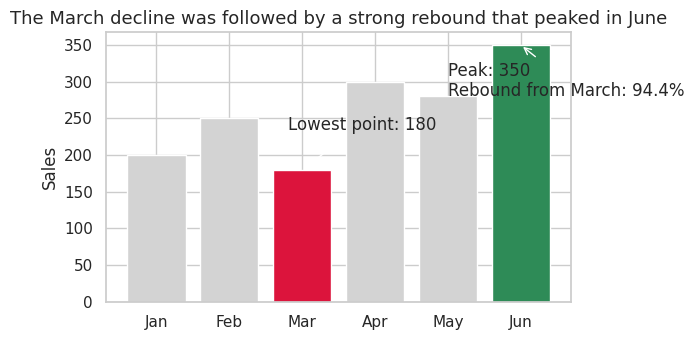

In [ ]:
lowest_idx = df["Sales"].idxmin()
highest_idx = df["Sales"].idxmax()
rebound_pct = ((df.loc[highest_idx, "Sales"] - df.loc[lowest_idx, "Sales"]) / df.loc[lowest_idx, "Sales"]) * 100

colors = []
for i in range(len(df)):
    if i == lowest_idx:
        colors.append("crimson")
    elif i == highest_idx:
        colors.append("seagreen")
    else:
        colors.append("lightgray")

plt.figure(figsize=(6,3.5))
plt.bar(df["Month"], df["Sales"], color=colors)
plt.title("The March decline was followed by a strong rebound that peaked in June", fontsize=13)
plt.ylabel("Sales")

plt.annotate(
    f"Lowest point: {df.loc[lowest_idx, 'Sales']}",
    xy=(lowest_idx, df.loc[lowest_idx, "Sales"]),
    xytext=(lowest_idx - 0.2, df.loc[lowest_idx, "Sales"] + 55),
    arrowprops=dict(arrowstyle="->")
)

plt.annotate(
    f"Peak: {df.loc[highest_idx, 'Sales']}\nRebound from March: {rebound_pct:.1f}%",
    xy=(highest_idx, df.loc[highest_idx, "Sales"]),
    xytext=(highest_idx - 1.0, df.loc[highest_idx, "Sales"] - 70),
    arrowprops=dict(arrowstyle="->")
)

plt.show()

**Your Task 2:** Create a persuasive chart that emphasizes **one decision-relevant insight** using color, annotation, or contrast.

Your chart must:
1. Focus on a single analytical claim  
2. Include at least **one quantitative annotation**  
3. Avoid unnecessary clutter  
4. Be followed by a **5–7 sentence interpretation** that explains:
   - the claim being made,
   - the evidence supporting it,
   - why it matters to the intended audience, and
   - one limitation or caution that should prevent overclaiming

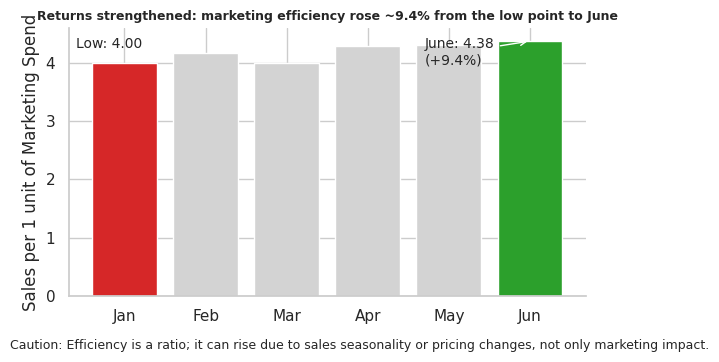

In [ ]:
# Emphasized Chart

# Compute improvement from the lowest efficiency month to June
low_eff_idx = df["Marketing_Efficiency"].idxmin()
low_eff = df.loc[low_eff_idx, "Marketing_Efficiency"]
jun_idx = df.index[df["Month"]=="Jun"][0]
jun_eff = df.loc[jun_idx, "Marketing_Efficiency"]
improve_pct = (jun_eff - low_eff) / low_eff * 100

colors = ["#D3D3D3"] * len(df)
colors[low_eff_idx] = "#D62728"  # low point in red
colors[jun_idx] = "#2CA02C"      # June in green

plt.figure(figsize=(6,3.5))
plt.bar(df["Month"], df["Marketing_Efficiency"], color=colors)

plt.title("Returns strengthened: marketing efficiency rose ~{:.1f}% from the low point to June".format(improve_pct),
          fontsize=9, weight="bold")
plt.ylabel("Sales per 1 unit of Marketing Spend")

# Quantitative annotations
plt.annotate(f"Low: {low_eff:.2f}",
             xy=(low_eff_idx, low_eff),
             xytext=(low_eff_idx-0.6, low_eff+0.25),
             arrowprops=dict(arrowstyle="->", lw=1),
             fontsize=10)

plt.annotate(f"June: {jun_eff:.2f}\n(+{improve_pct:.1f}%)",
             xy=(jun_idx, jun_eff),
             xytext=(jun_idx-1.3, jun_eff-0.4),
             arrowprops=dict(arrowstyle="->", lw=1),
             fontsize=10)

# Clutter control: remove top/right spines
sns.despine()

# Limitation note
plt.figtext(0.01, -0.02,
            "Caution: Efficiency is a ratio; it can rise due to sales seasonality or pricing changes, not only marketing impact.",
            ha="left", fontsize=9)

plt.tight_layout()
plt.show()

INTERPRETATION

* The chart demonstrates that marketing efficiency strengthened over the period, peaking with the best performance in June.

* By highlighting the climb from the red low point to the green high point, the visual quantifies a clear upward trend.

* This improvement is vital for decision-makers, as rising returns provide a much stronger justification for increasing investment.

* Visual contrast is used sparinglu to direct attention toward this specific decision signal rather than unnecessary decoration.

* However, efficiency is influenced by external factors like seasonality and pricing, so these results dont strictly prove casuality.

* Given the small six-month window, any spend increase should be paired with a cautious "test-and-learn" approach.

Step 4. Build a Visual Story with Context, Complication, and Implication

Communication should show progression. Instead of presenting unrelated charts, build a sequence in which each figure performs a role in the argument: establish the baseline, surface the disruption, and show the implication or recovery.

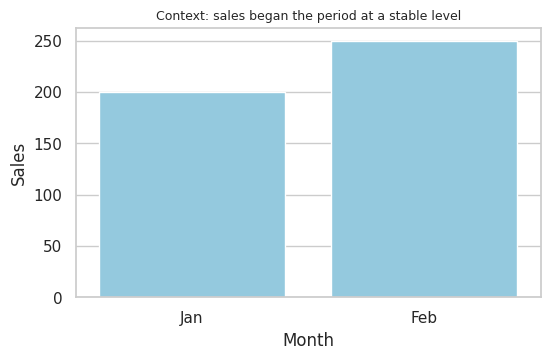

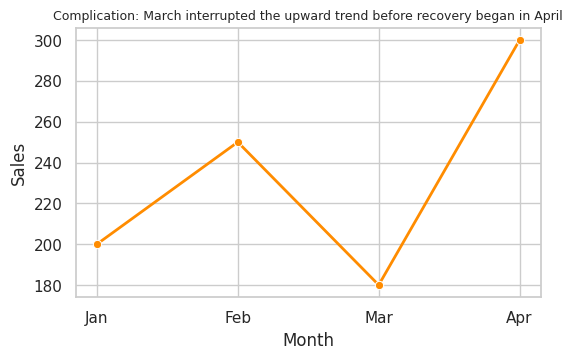

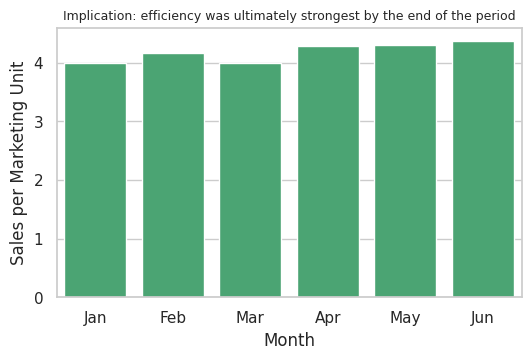

In [ ]:
# Beginning: establish the baseline
plt.figure(figsize=(6,3.5))
sns.barplot(x="Month", y="Sales", data=df.iloc[:2], color="skyblue")
plt.title("Context: sales began the period at a stable level", fontsize=9)
plt.ylabel("Sales")
plt.show()

# Middle: identify the complication
plt.figure(figsize=(6,3.5))
sns.lineplot(x="Month", y="Sales", data=df.iloc[:4], color="darkorange", marker="o", linewidth=2)
plt.title("Complication: March interrupted the upward trend before recovery began in April", fontsize=9)
plt.ylabel("Sales")
plt.show()

# End: communicate implication
plt.figure(figsize=(6,3.5))
sns.barplot(x="Month", y="Marketing_Efficiency", data=df, color="mediumseagreen")
plt.title("Implication: efficiency was ultimately strongest by the end of the period", fontsize=9)
plt.ylabel("Sales per Marketing Unit")
plt.show()

**Your Task 3:** Write a short analytical narrative of **100–150 words** using the structure below:

- **Context:** What was the initial situation?
- **Complication:** What changed, declined, or became uncertain?
- **Implication/Recommendation:** What does the evidence suggest should happen next?

Your response should read like a short briefing note rather than a casual observation. Make sure the recommendation is directly tied to the evidence shown in the charts.

ANALYTICAL NARRATIVE

Context: Sales began the period at a reasonable level and marketing spend remained proportionate, providing a baseline for evaluating whether investment is translating into returns.

Complication: Performance became volatile when sales dropped sharply in March, creating uncertainty about whether demand weakened or whether execution factors reduced short-term effectiveness.

Implication/Recommendation: The recovery that followed—ending with June as the strongest month—suggests the downturn was not permanent and that marketing efficiency held up rather than collapsing. Based on this evidence, the recommended next step is to increase marketing investment cautiously (ex., incremental uplift rather than a step-change) while tracking efficiency and sales response monthly. Because the dataset is small and causal drivers are not isolated, the decision should be paired with guardrails and measurement to avoid overreacting to short-term swings.

Step 5. Integrate the Message into a Final Decision-Focused Visualization

A final influence chart should combine clarity, evidence, and actionability. The goal is not to include everything, but to present enough evidence to support a recommendation without overwhelming the audience.

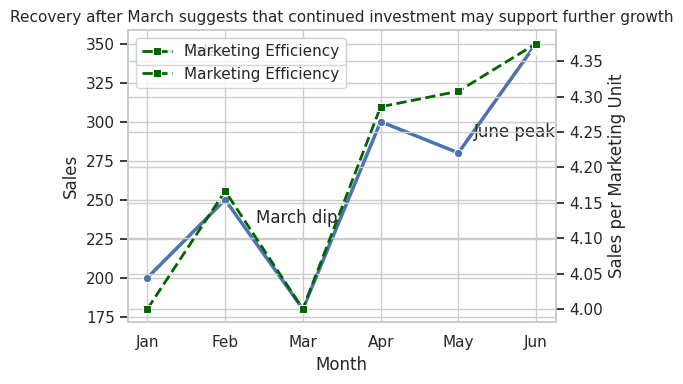

In [ ]:
fig, ax1 = plt.subplots(figsize=(6,4))

sns.lineplot(x="Month", y="Sales", data=df, marker="o", linewidth=2.5, ax=ax1, label="Sales")
ax1.set_ylabel("Sales")
ax1.set_title("Recovery after March suggests that continued investment may support further growth", fontsize=11)

ax2 = ax1.twinx()
sns.lineplot(
    x="Month",
    y="Marketing_Efficiency",
    data=df,
    marker="s",
    linewidth=2,
    linestyle="--",
    ax=ax2,
    color="darkgreen",
    label="Marketing Efficiency"
)
ax2.set_ylabel("Sales per Marketing Unit")

ax1.annotate(
    "March dip",
    xy=(2, df.loc[2, "Sales"]),
    xytext=(1.4, df.loc[2, "Sales"] + 55),
    arrowprops=dict(arrowstyle="->")
)
ax1.annotate(
    "June peak",
    xy=(5, df.loc[5, "Sales"]),
    xytext=(4.2, df.loc[5, "Sales"] - 60),
    arrowprops=dict(arrowstyle="->")
)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

plt.tight_layout()
plt.show()

**Task 4:** Create your own final decision-focused visualization and accompany it with an **executive interpretation of 75-120 words**.

Your final output must:
1. Communicate a single recommendation or decision implication  
2. Use a strong takeaway title  
3. Include annotation or labeling that reduces ambiguity  
4. Avoid overloading the figure with unnecessary detail  
5. Be suitable for inclusion in a presentation or report

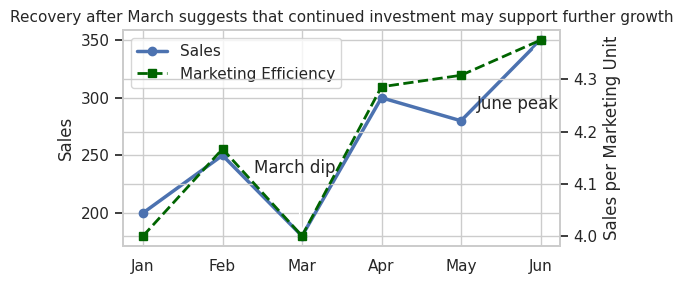

In [ ]:
fig, ax1 = plt.subplots(figsize=(6,3))

line1 = ax1.plot(df["Month"], df["Sales"], marker="o", linewidth=2.5, label="Sales")
ax1.set_ylabel("Sales")
ax1.set_title("Recovery after March suggests that continued investment may support further growth", fontsize=11)

ax2 = ax1.twinx()
line2 = ax2.plot(
    df["Month"],
    df["Marketing_Efficiency"],
    marker="s",
    linewidth=2,
    linestyle="--",
    color="darkgreen",
    label="Marketing Efficiency"
)
ax2.set_ylabel("Sales per Marketing Unit")

ax1.annotate(
    "March dip",
    xy=(2, df.loc[2, "Sales"]),
    xytext=(1.4, df.loc[2, "Sales"] + 55),
    arrowprops=dict(arrowstyle="->")
)
ax1.annotate(
    "June peak",
    xy=(5, df.loc[5, "Sales"]),
    xytext=(4.2, df.loc[5, "Sales"] - 60),
    arrowprops=dict(arrowstyle="->")
)

lines = line1 + line2
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper left")

plt.tight_layout()
plt.show()

EXECUTIVE INTERPRETATION

Sales showed a clear recovery after the March decline, finishing with a June peak, while marketing efficiency also reached its strongest level at the end of the period. Together, these signals suggest that increasing marketing investment is reasonable as long as returns remain protected. The recommended action is a cautious, controlled spend increase paired with monthly tracking of efficiency to confirm the uplift is sustainable. Because the data covers only six months and does not isolate other business drivers, the pattern should be treated as directional evidence rather than causal proof. If efficiency starts to fall, the spend increase should be paused and re-optimized.

---

**5. Supplementary Activity**

Use a small real-world dataset from a credible public source (for example: government open data portals, Kaggle, World Bank, or a peer-reviewed supplementary dataset).

**Requirements:**
1. Select a dataset with at least **8 observations** and a decision-relevant question.
2. Identify a **specific audience** and the **decision** the audience must make.
3. Create **two alternative visualizations** of the same data for the same audience.
4. Critique both versions, then select the stronger one and explain why.
5. Add one annotation that strengthens interpretation and one note that communicates limitation, uncertainty, or possible bias.
6. Cite the dataset source and any reference used to support your design choices.

**Expectation:** Your submission should demonstrate not only visual clarity, but also argument quality, methodological transparency, and ethical restraint.

**6. Conclusion/Learnings/Analysis:**

In **5-7 sentences**, reflect on how visualization choices can shape managerial or stakeholder decisions. Discuss what you learned about the relationship among evidence, persuasion, and ethical responsibility. Use this space to explain how your approach changed from simply “making charts” to designing visuals that support action.

1. Dataset:
Advertising Budget and Sales

Contains 200 observations where row represents a distinct market or campance instance. And it also shows how much advertising budget was allocation to three different media channels - TV, Radio and Newspaper.

Source: https://www.kaggle.com/datasets/yasserh/advertising-sales-dataset

2. Problem Statement

Given a limited marketing budget, how should advertising spend be allocated across TV, Radio, and Newspaper to support higher sales outcomes?

3. Intended Audience

Marketing leadership or senior decision-makers responsible for allocating advertising budgets.

4. Decision

For the next campaign, should we increase total spend, or reallocate spend toward the most effective channel mix?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Load the Kaggle dataset (uploaded to Colab)
df = pd.read_csv("/content/Advertising Budget and Sales.csv")

# Rename the first column as an ID (it is just a row index)
df = df.rename(columns={df.columns[0]: "Market_ID"})

# Clean column names
df.columns = [c.strip() for c in df.columns]

# Rename variables for clarity
df = df.rename(columns={
    "TV Ad Budget ($)": "TV",
    "Radio Ad Budget ($)": "Radio",
    "Newspaper Ad Budget ($)": "Newspaper",
    "Sales ($)": "Sales"
})

df.head()

,Market_ID,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


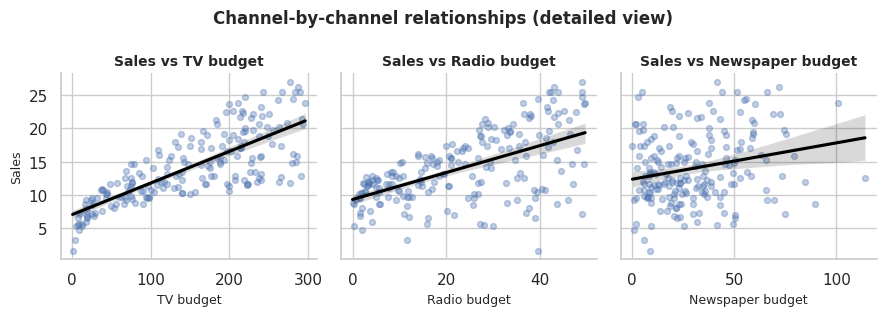

In [ ]:
# Chart 1: Small Multiple Scatterplots

fig, axes = plt.subplots(1, 3, figsize=(9, 3.2), sharey=True)

for ax, col, color in zip(
    axes,
    ["TV", "Radio", "Newspaper"],
    ["#1F77B4", "#FF7F0E", "#7F7F7F"]
):
    sns.regplot(
        x=col, y="Sales", data=df, ax=ax,
        scatter_kws={"alpha": 0.35, "s": 18},
        line_kws={"color": "black"}
    )
    ax.set_title(f"Sales vs {col} budget", fontsize=10, weight="bold")
    ax.set_xlabel(f"{col} budget", fontsize=9)
    ax.set_ylabel("Sales" if col == "TV" else "", fontsize=9)

fig.suptitle(
    "Channel-by-channel relationships (detailed view)",
    fontsize=12, weight="bold"
)

sns.despine()
plt.tight_layout(pad=1)
plt.show()

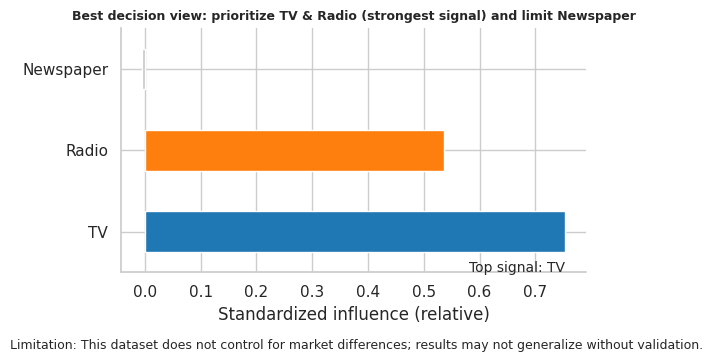

In [ ]:
# Chart 2: Ranked Influence Bar Chart
plt.figure(figsize=(6,3.5))

ax = std_coefs.reindex(["TV","Radio","Newspaper"]).plot(
    kind="barh", color=["#1F77B4","#FF7F0E","#C7C7C7"]
)

plt.title("Best decision view: prioritize TV & Radio (strongest signal) and limit Newspaper",
          fontsize=9, weight="bold")
plt.xlabel("Standardized influence (relative)")

# Annotation strengthens interpretation
top_driver = std_coefs.idxmax()
plt.annotate(f"Top signal: {top_driver}",
             xy=(std_coefs.max(), 0), xycoords=("data","axes fraction"),
             ha="right", fontsize=10)

# Limitation note (bias/uncertainty)
plt.figtext(0.01, -0.02,
            "Limitation: This dataset does not control for market differences; results may not generalize without validation.",
            ha="left", fontsize=9)

sns.despine()
plt.tight_layout()
plt.show()

5. CRITIQUE

Version 1: The three scatterplots provide transparency and allow deeper inspection of the relationship between each channel budget and Sales, but they impose higher cognitive load on decision-makers because the audience must compare three panels and infer the conclusion themselves.

Version 2: The ranked influence chart is more decision-effective because it directly answers the allocation question (“which channel matters most?”) with a single, interpretable view and an annotated takeaway.

The stronger choice for the stated audience is Version 2, because it compresses complexity into one clear recommendation while still including a limitation note to avoid overclaiming.  The takeaway-title approach strengthens actionability by stating what leaders should do with the insight.

6. Conclusion / Learnings / Analysis

This supplementary activity showed how visualization choices can strongly influence how managers interpret evidence and make decisions. Rather than presenting many exploratory charts, I learned to focus on visuals that clearly support a specific action and reduce the effort required from the audience. Using takeaway titles, selective emphasis, and simplified comparisons helped shift the work of interpretation from the stakeholder to the visualization itself. At the same time, ethical responsibility meant being explicit about limitations and avoiding claims of causality that the data cannot support. Overall, my approach evolved from simply making charts to intentionally designing visuals as decision tools that balance evidence, persuasion, and integrity.